In [1]:
%matplotlib inline
import os
import glob
import numpy as np
from galfitx.source_detection import SExtractor_HDR
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import shutil
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.io import ascii
from astropy.visualization import simple_norm
from astropy.coordinates import SkyCoord
from pathlib import Path

# ── import plotting helpers ───────────────────────────────────────────────────
import sys
from pathlib import Path as Path2
path = Path2('~/code_package').expanduser()
sys.path.append(str(path))
import matplotlib.pyplot as plt
from my_astro_tools import my_im_show,set_plot_style
set_plot_style()    

/home/zhanghan/anaconda3/envs/galfitx_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The SFD'98 dust map is not in the data directory:

    /home/zhanghan/anaconda3/envs/galfitx_env/lib/python3.12/site-packages/dustmaps/data

To change the data directory, call:

    from dustmaps.config import config
    config['data_dir'] = '/path/to/data/directory'

To download the SFD'98 map to the data directory, call:

    import dustmaps.sfd
    dustmaps.sfd.fetch()



In [2]:
sci_dir = '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/'
sci_files = sorted(glob.glob(os.path.join(sci_dir, '*a3001_match.fits')))
#sci_files = sorted(glob.glob(os.path.join(sci_dir, '*tweakreg.fits')))
print(sci_files)
print(len(sci_files))
psf_out_path = sci_dir + "psfex/"
#os.makedirs(psf_out_path, exist_ok=True)

['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca2_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca3_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca4_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb1_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb2_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb3_a3001_match.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_0210

In [3]:
sci_file = sci_files[3]
band = sci_file.split('/')[-3].split('_')[-1]
print(sci_file, band)

/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca4_a3001_match.fits F115W


#### Step 1. Read the corresponding star catalog from resampled image

In [4]:
## catalog constructed from empirical_psf.ipynb
data = ascii.read(f'./data_example/star_ids_{band}.txt', comment='#')
star_id_master = np.array(data['star_id'])
print(len(star_id_master),star_id_master)
catlog_file_resample = "/RS2423/JWST/grism/data/direct_image/sextractor/"+band+"/"+"outcat_"+band
outtab_resample = ascii.read(catlog_file_resample)
mask_resample = np.isin(np.asarray(outtab_resample['label']), np.asarray(star_id_master))
sub_resample = outtab_resample[mask_resample]
star_coords = SkyCoord(ra=sub_resample['ra'], dec=sub_resample['dec'], unit=(u.deg, u.deg))
print(star_coords)

31 [ 5901  7507  7651  7684  8146  8638  8894  9230  9252  9589  9758 10237
 10462 11187 11691 12013 12369 12840 13494 13497 13788 14167 14298 15152
 16394 16761 16951 19830 19888 22384 22585]
<SkyCoord (ICRS): (ra, dec) in deg
    [(15.0766153 , 28.05326838), (15.04923614, 28.07812882),
     (15.10276889, 28.00859606), (15.08814809, 28.02716283),
     (15.0747858 , 28.04102493), (15.08741693, 28.02130422),
     (15.08575442, 28.02202458), (15.09303898, 28.0105939 ),
     (15.05403861, 28.06048553), (15.05932334, 28.05200869),
     (15.08435635, 28.01897616), (15.08078141, 28.02115697),
     (15.0504766 , 28.05825701), (15.08139527, 28.01335622),
     (15.04646272, 28.05450945), (15.08842453, 27.99878603),
     (15.03674736, 28.0624797 ), (15.07042928, 28.0157931 ),
     (15.04309462, 28.04621849), (15.04660589, 28.04172062),
     (15.06833291, 28.01138069), (15.03496776, 28.05107783),
     (15.02083887, 28.06827143), (15.07812378, 27.99095002),
     (15.00667901, 28.0758244 ), (15.036

In [5]:
with fits.open(sci_file) as hdul:
    hdul.info()
    det = hdul[0].header.get("DETECTOR", "NRCA1").upper()
    hdr = hdul[1].header
    data = hdul[1].data  # or hdul['SCI'].data
    coverage_mask = ((data == 0) | np.isnan(data))  # True for pixels with zero coverage or NaN
    print(f"Shape: {data.shape}")
    print(f"Detector: {det}")
    print(f"Min: {np.nanmin(data):.6f}")
    print(f"Max: {np.nanmax(data):.6f}")
    print(f"Mean: {np.nanmean(data):.6f}")
    print(f"Median: {np.nanmedian(data):.6f}")
    print(f"Std: {np.nanstd(data):.6f}") 

Filename: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca4_a3001_match.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     376   ()      
  1  SCI           1 ImageHDU       156   (2048, 2048)   float32   
  2  ERR           1 ImageHDU        10   (2048, 2048)   float32   
  3  DQ            1 ImageHDU        11   (2048, 2048)   int32 (rescales to uint32)   
  4  AREA          1 ImageHDU         9   (2048, 2048)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2048, 2048)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2048, 2048)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2048, 2048)   float32   
  8  ASDF          1 BinTableHDU     11   1R x 1C   [736366B]   
Shape: (2048, 2048)
Detector: NRCA4
Min: -4.389713
Max: 1446.558960
Mean: 0.011393
Median: 0.001465
Std: 1.679284


In [6]:
print(np.sum(np.isfinite(data)))
print(np.sum(np.isnan(data)))

4149906
44398


In [7]:
pixel_sr = hdr['PIXAR_SR']
pixel_scale = np.sqrt(hdr['PIXAR_A2']) #arcsec/pixel
mag_zeropoint = -2.5 * np.log10((u.MJy / u.sr * (pixel_sr*u.sr**2) / (3631 * u.Jy)).cgs.value)
print(mag_zeropoint,pixel_scale) 

28.02169112281333 0.03091007316632683


In [8]:
print(f"Coverage mask: {np.sum(coverage_mask)}")

Coverage mask: 44398


#### SExtractor catalog

In [ ]:
for i, sci_file in enumerate(sci_files):
    out_path = sci_dir + "sextractor/" + f"stage3_{i}/"+"/"
    os.makedirs(out_path, exist_ok=True)
    print("Processing science file %d: %s to %s"%(i, sci_file, out_path))
    outtab, outsegm = SExtractor_HDR(
        filename=sci_file,
        file_ext=1,
        catalog_name=("coldcat_"+band, "hotcat_"+band, "outcat_"+band),
        segmap_name=("coldseg_"+band+".fits", "hotseg_"+band+".fits", "outseg_"+band+".fits"),
        path=out_path,
        back_type=(True, True),
        back_value=(0.0, 0.0),
        detect_thresh=(3, 2),
        back_size=(128, 32),
        mag_zeropoint=mag_zeropoint,
        pixel_scale=pixel_scale,
        fwhm_arcsec=0.13,
        verbose=True,
        coverage_mask = coverage_mask,
        nnw_sex = '/home/zhanghan/sextractor/config/default.nnw'
    )

#outtab = ascii.read(catalog_file)

Processing science file 0: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_match.fits to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/sextractor/stage3_0//
**********Cold Detection**********

Source Extraction Begins.......
detection image: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_match.fits


Weight Image Preprocessing Finished
  weight_type = NONE


Automatic Background Estimation and Subtraction Finished
  background size = 128
  background filter size = 3


Detection Finished
  detect_minarea = 5
  detect_thresh = 3
  threshold (above background) = 0.1352899670600891
Found 132 sources.


Deblending skipped.


Cleaning skipped.


There are 132 objects in the catalog.

obj_crowded [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, Fa

Weight Image Preprocessing Finished
  weight_type = NONE


Automatic Background Estimation and Subtraction Finished
  background size = 32
  background filter size = 3


Detection Finished
  detect_minarea = 5
  detect_thresh = 2
  threshold (above background) = 0.08999690413475037
Found 242 sources.


Deblending skipped.


Cleaning skipped.


There are 242 objects in the catalog.

obj_crowded [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, True, False, False, True, True, False, False, False, False, False, False, False, True, False, False, False, False,

In [ ]:
from psfex_helper import star_pre_select, star_master_cat, build_input_ldac, psfex_config, build_merged_ldac
from galfitx.create_psf import run_psfex

Could not import regions, which is required for some of the functionalities of this module.


In [ ]:
# ========================================================================
# User-defined parameters - modify these for your data
# ========================================================================
sci_images = sci_files           # Path to science image
file_ext = 1

template_file = "/home/zhanghan/output_assoc_temp.cat"  # Template LDAC file

output_dir = psf_out_path # Output directory
output_ldac_pre = psf_out_path + "psfex_" + band           # Output LDAC catalog name
config_file = os.path.join(output_dir, "config"+band+".psfex")

# Star selection criteria
mag_bright_limit = 19.0            # Bright magnitude limit
mag_faint_limit = 27.0             # Faint magnitude limit
elong_max = 1.5                    # Maximum elongation for star selection
class_star_min = 0.96              # Minimum star class

# Cutout parameters
cutout_size = 135                  # Size of star cutouts (pixels)

# PSFEx configuration parameters
psf_sampling = 0.5                 # Sampling step (0.0 = auto)
psf_size = (265, 265)              # Output PSF size
sample_minsn = 100                 # Minimum S/N for star selection

# Image metadata 
fwhm_arcsec_list = {'F115W': 0.06, 'F200W':0.073, 'F356W':0.14}
mag_zeropoint = mag_zeropoint      # Magnitude zero-point
ref_pixel_scale = pixel_scale      # Pixel scale (arcsec/pixel)

In [ ]:
# ========================================================================
# Step 1: Build LDAC catalog for PSFEx
# ========================================================================
print("=" * 60)
print("Step 1: Building LDAC catalog for PSFEx")
print("=" * 60)

output_dir = os.path.abspath(output_dir)  # get absolute path
current_dir = os.path.abspath(os.getcwd())
if output_dir == current_dir:
    raise ValueError("Error: Trying to delete current directory! Aborting.")
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.mkdir(output_dir)

for i, sci_image in enumerate(sci_images):
    print("Processing science image:", sci_image)
    out_path = sci_dir + "sextractor/" + f"stage3_{i}/"+"/"
    catalog_file = out_path+"outcat_"+band            # SExtractor catalog (ASCII)
    seg_file = out_path+"outseg_"+band+".fits"      # SExtractor segmentation map
    outtab1, star_id = star_pre_select(catalog_file=catalog_file,
                                        mag_bright_limit=mag_bright_limit,
                                        mag_faint_limit=mag_faint_limit,
                                        crossmatch=False,
                                        fwhm_arcsec=fwhm_arcsec_list[band],
                                        elong_max=elong_max,
                                        class_star_min=class_star_min
                                        ) 
    target_coords = SkyCoord(ra=outtab1['ra'], dec=outtab1['dec'], unit='deg')

    # Find matches within 0.5 arcsec
    idx, sep2d, _ = target_coords.match_to_catalog_sky(star_coords)

    # Keep only rows where separation <= 0.5 arcsec
    match_mask = sep2d <= 0.5 * u.arcsec
    matched_outtab1 = outtab1[match_mask]
    matched_star_ids = matched_outtab1['label']
    build_input_ldac(
        sci_image=sci_image,
        catalog_file=catalog_file,
        seg_file=seg_file,
        output_ldac=f"{output_ldac_pre}_{i}.cat",
        file_ext=file_ext,
        mag_bright_limit=mag_bright_limit,
        mag_faint_limit=mag_faint_limit,
        cutout_size=cutout_size,
        star_id_pre=matched_star_ids,
        save_cutouts=True,
        cutouts_dir=os.path.join(output_dir, "star_cutouts_"+band+str(i)),
        template_file=template_file,
        fwhm_arcsec=fwhm_arcsec_list[band],
        mag_zeropoint=mag_zeropoint,
        ref_pixel_scale=ref_pixel_scale,
        star_coords_path=os.path.join(output_dir, f"star_coords_{band}_{i}.txt")
    )

# ========================================================================
# Step 2: Generate PSFEx configuration file
# ========================================================================
print("\n" + "=" * 60)
print("Step 2: Generating PSFEx configuration file (constant PSF)")
print("=" * 60)

psfex_config(
    output_config=config_file,
    psf_sampling=psf_sampling,
    psf_size=psf_size,
    sample_autoselect=True,
    sample_fwhmrange="0.5, 10",
    sample_minsn=sample_minsn,
    psfvar_degrees=0,
    outcat_name=os.path.join(output_dir, "psfex_cat_"+band+".txt")  # Constant PSF
)

Step 1: Building LDAC catalog for PSFEx


Processing science image: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_match.fits
2 sources satisfy stellar criteria.
2 sources satisfy stellar criteria.
0 out of 0 stars are fully within the image and have been cut out.
Processing science image: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca2_a3001_match.fits
1 sources satisfy stellar criteria.
1 sources satisfy stellar criteria.
0 out of 0 stars are fully within the image and have been cut out.
Processing science image: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca3_a3001_match.fits
0 sources satisfy stellar criteria.
0 sources satisfy stellar criteria.
0 out of 0 stars are fully within the image and have been cut out.
Processing science image: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_0000

In [ ]:
ldac_files = sorted(glob.glob(f"{output_ldac_pre}*.cat"))
print(len(ldac_files))
build_merged_ldac(
    ldac_files = ldac_files,
    template_file = template_file,
    merged_output = f"{output_ldac_pre}_merged.cat",
    cutout_size = cutout_size,
    mag_zeropoint = mag_zeropoint,
    ref_pixel_scale = ref_pixel_scale,
    fwhm_arcsec = fwhm_arcsec_list[band])

45
Pooled 47 stars from 45 exposures.
Merged LDAC written to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged.cat
Merged catalog finalized: 47 stars, NAXIS1/2 set to 8192


In [ ]:
with fits.open(f"{output_ldac_pre}_merged.cat", mode='update') as hdul:
    hdul.info()
    cat = Table(hdul[2].data)

Filename: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged.cat
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  LDAC_IMHEAD    1 BinTableHDU     12   1R x 1C   [9840A]   
  2  LDAC_OBJECTS    1 BinTableHDU     57   47R x 13C   [1E, 1E, 1D, 1D, 1E, 1E, 1I, 18225E, 1E, 1E, 1E, 1D, 1J]   


In [ ]:
cat

X_IMAGE,Y_IMAGE,ALPHA_J2000,DELTA_J2000,FLUX_RADIUS,ELONGATION,FLAGS,VIGNET,FLUX_APER,FLUXERR_APER,SNR_WIN,VECTOR_ASSOC,NUMBER_ASSOC
float32,float32,float64,float64,float32,float32,int16,"float32[135,135]",float32,float32,float32,float64,int32
1428.529,1759.711,15.08742048429938,28.02130520871215,1.0310459,1.1383986,0,0.03745125 .. 0.046394985,906.1488,0.6275508,1443.945,1428.529052734375,1
1400.16,377.397,15.05048034053371,28.058257096875526,0.96422726,1.0461092,0,-0.095183276 .. -0.018671772,39.519123,0.3326824,118.78934,1400.1600341796875,1
1488.322,942.476,15.088428245603481,27.998786717621858,0.9824378,1.0991155,0,0.10741099 .. 0.034392286,18.290134,0.32100713,56.977345,1488.322021484375,1
1000.417,1373.537,15.070434795051664,28.01579320438185,0.9871375,1.0623275,0,-0.012656536 .. -0.13909332,47.03318,0.34254158,137.30649,1000.4169921875,1
1282.945,1849.335,15.085758223500278,28.022026306620855,0.9516095,1.0870988,0,0.054641157 .. 0.024621755,42.077435,0.27962205,150.47968,1282.9449462890625,1
976.734,1396.745,15.070435684387963,28.01579325740487,0.9838985,1.1213102,0,-0.029420536 .. 0.002485159,46.6288,0.32933164,141.58615,976.7340087890625,1
1280.405,1866.577,15.068338747488609,28.011380626548608,0.9674659,1.0276357,0,-0.10822807 .. 0.013573992,26.461954,0.3089767,85.643845,1280.405029296875,1
1259.565,1872.444,15.085759343721627,28.02202619368485,0.9536894,1.074241,0,-0.050160497 .. 0.09120081,40.81613,0.28631398,142.55724,1259.56494140625,1
1449.322,927.473,15.088429751237893,27.998787033566234,0.94179106,1.0748534,0,-0.034975328 .. 0.003432446,17.742092,0.3047804,58.212708,1449.322021484375,1


In [ ]:
# ========================================================================
# Step 3: Run PSFEx
# ========================================================================
print("\n" + "=" * 60)
print("Step 3: Running PSFEx")
print("=" * 60)

psf_file = run_psfex(
    catalog=f"{output_ldac_pre}_merged.cat",
    config=config_file,
    output_dir=output_dir,
)

print("\n" + "=" * 60)
print("PSFEx workflow completed successfully!")
print(f"PSF model saved to: {psf_file}")
print(f"Output directory: {output_dir}")
print("=" * 60)


Step 3: Running PSFEx
Running PSFEx...


> 
----- PSFEx 3.17.1 started on 2026-07-21 at 19:43:45 with 1 thread

> 
----- 1 input catalogues:
psfex_F115W_merged.c:  "no ident        "    1 extension      47 detections

> Initializing contexts...
> Reading data from psfex_F115W_merged...
> Computing final PSF model for psfex_F115W_merged...
   filename      [ext] accepted/total samp. chi2/dof FWHM ellip. resi. asym.
> Computing diagnostics for psfex_F115W_merged...
psfex_F115W_merge           39/39      0.50 122.33   1.47  0.03  0.15  0.13
> Saving PSF model and metadata for psfex_F115W_merged...
> 
> All done (in 19.0 s)


PSF model written to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged.psf
PSF FITS saved to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged_psf.fits
Radial profile saved to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged_radial_profile.png
FWHM = 1.6405257195100282

PSFEx workflow completed successfully!
PSF model saved to: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged.psf
Output directory: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex


In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

psf_file = psf_out_path + "psfex_"+band+"_merged_psf.fits"

with fits.open(psf_file) as hdul:
    hdul.info()
    psf_data = hdul[0].data  

Filename: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/psfex/psfex_F115W_merged_psf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (133, 133)   float64   


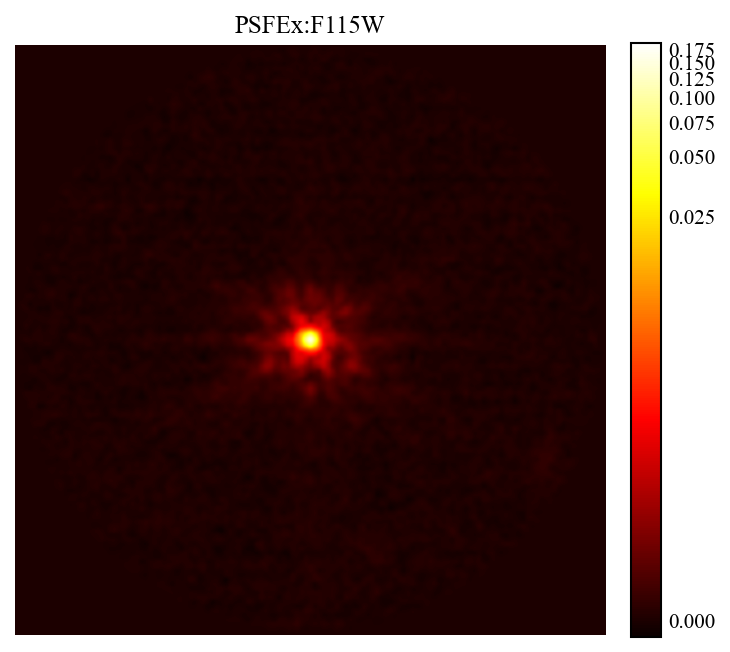

In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
norm = simple_norm(psf_data, stretch='log')
im = ax.imshow(psf_data, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
ax.set_title("PSFEx:"+band)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# PSFEx output — NUMBER is the 1-indexed row in the input LDAC
psfex_cat = ascii.read(os.path.join(output_dir, "psfex_cat_"+band+".txt"))
print(psfex_cat.columns)

<TableColumns names=('SOURCE_NUMBER','EXTENSION','CATALOG_NUMBER','X_IMAGE','Y_IMAGE','DELTAX_IMAGE','DELTAY_IMAGE','NORM_PSF','CHI2_PSF','RESI_PSF')>


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Webb PSF at resampling pixel scale
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import stpsf
nrc = stpsf.NIRCam()
nrc.filter = band
nrc.pixelscale = pixel_scale
nrc.detector = "NRCA1"
Webbpsf_fits = nrc.calc_psf(fov_pixels=cutout_size)
Webbpsf = Webbpsf_fits[3].data 

In [ ]:
from photutils.psf import fit_fwhm
print(f"FWHM for mpsf: {band}")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stage3psf = fit_fwhm(psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stage3psf} arcsec")
print("="*60)
print(f"FWHM for WebbPSF: {band}")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_webbpsf = fit_fwhm(Webbpsf)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_webbpsf} arcsec")

FWHM for mpsf: F115W
pixel scale = 0.03091007316632683 arcsec/pixel
PSF FWHM = 0.05070877002129594 arcsec
FWHM for WebbPSF: F115W
pixel scale = 0.03091007316632683 arcsec/pixel
PSF FWHM = 0.039532570186554594 arcsec


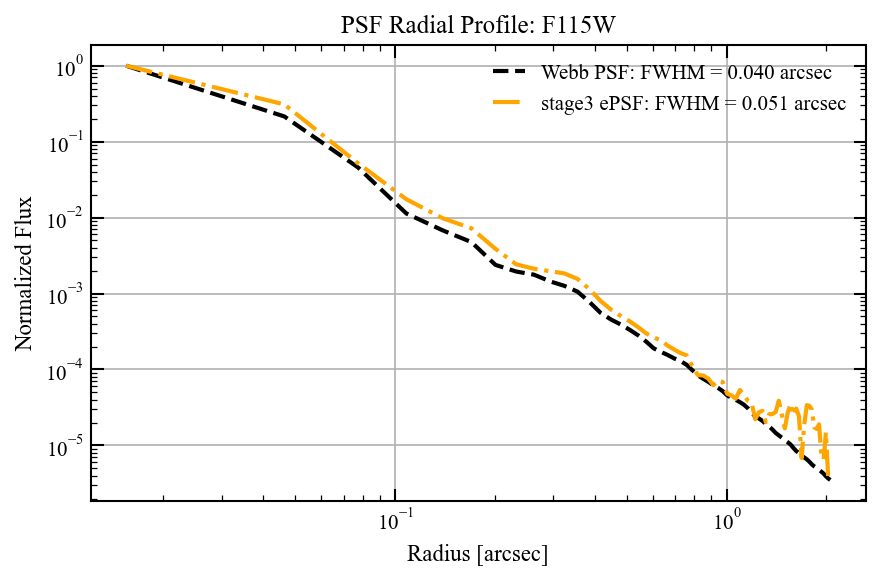

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Radial Profile
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from photutils.profiles import RadialProfile
from photutils.centroids import centroid_2dg
from photutils.profiles import CurveOfGrowth

def plot_psf_radial_profile(psf, ax, pixel_scale=0.031, label='Stacked PSF', color='black', linestyle='-'):
    try:
        psf_center = centroid_2dg(psf)
    except Exception as e:
        print(f"Centroid fitting failed: {e}")
        peak_idx = np.argmax(psf)
        psf_center = (peak_idx % psf.shape[1], peak_idx // psf.shape[1])
    max_radius = min(psf.shape) // 2  
    radii = np.linspace(0.1, max_radius, int(max_radius / 1.0) + 1)
    rp_psf = RadialProfile(psf, psf_center, radii)
    psf_profile = rp_psf.profile
    peak_psf = np.nanmax(psf_profile)
    if peak_psf > 0:
        psf_profile = psf_profile / peak_psf
    ax.plot(rp_psf.radius * pixel_scale, psf_profile, 
            color=color, linewidth=2, linestyle=linestyle, label=label)
            
def plot_psf_enclosed_energy(psf,ax,pixel_scale=0.031,label='Stacked PSF',color = 'black',linestyle = '-'):
    try:
        psf_center = centroid_2dg(psf)
    except Exception as e:
        print(f"Centroid fitting failed: {e}")
        peak_idx = np.argmax(psf)
        psf_center = (peak_idx % psf.shape[1], peak_idx // psf.shape[1])
    max_radius = min(psf.shape) // 2  # Use min to avoid going out of bounds
    radii = np.linspace(0.1, max_radius, int(max_radius / 1.0) + 1)
    cog = CurveOfGrowth(psf, psf_center, radii)
    cog.normalize(method='max')
    ax.plot(cog.radius*pixel_scale, cog.profile, color=color, linewidth=2,linestyle = linestyle,
            label=label)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plot_psf_radial_profile(Webbpsf, ax, pixel_scale = pixel_scale, label=f"Webb PSF: FWHM = {fwhm_webbpsf:.3f} arcsec", color='black',linestyle = '--')
plot_psf_radial_profile(psf_data, ax, pixel_scale = pixel_scale, label=f'stage3 ePSF: FWHM = {fwhm_stage3psf:.3f} arcsec', color='orange', linestyle = '-.')
plot_psf_enclosed_energy(Webbpsf, ax, pixel_scale = pixel_scale, label=f"Webb PSF: FWHM = {fwhm_webbpsf:.3f} arcsec", color='black',linestyle = '--')
plot_psf_enclosed_energy(psf_data, ax, pixel_scale = pixel_scale, label=f'stage3 ePSF: FWHM = {fwhm_stage3psf:.3f} arcsec', color='orange', linestyle = '-.')
for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid()
axs[0].set_xlabel('Radius [arcsec]')
axs[0].set_ylabel('Normalized Flux')
axs[0].set_title(f'PSF Radial Profile: {band}')
axs[1].set_xlabel('Radius [arcsec]')
axs[1].set_ylabel('Enclosed Energy')
axs[1].set_title(f'PSF Cumulated Profile: {band}')

plt.tight_layout()
plt.show()